# Testing ocean data on ACCESS-Vis tools

In [1]:
import accessvis
import time
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import intake
import cmocean as cm
import cartopy.crs as ccrs

accessvis.resolution_selection(default=1)

Low-res 2K - fast for testing
Mid-res 4K - good enough for full earth views
High res 8K - better if showing close up at country scale
Ultra-high 16K - max detail but requires a fast GPU with high memory


Dropdown(description='Detail:', options=(('Low-res 2K', 1), ('Mid-res 4K', 2), ('High-res 8K', 3), ('Ultra-hig…


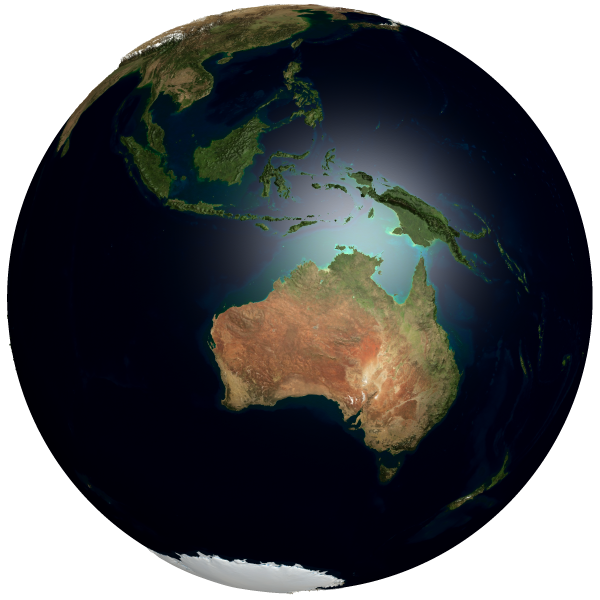

In [2]:
lv = accessvis.plot_earth(texture='bluemarble', background="white", vertical_exaggeration=20)
lv.rotation(30.0, 230.0, -30.0) #Rotate to Australia
lv.translation(0.0, 0.0, -17)
lv.display(resolution=(600,600))

# Load ocean data to plot on this globe

In [3]:
esm_file='/g/data/nm03/lxy581/archive/tides_004_global_sigma_SAL_x06/output002/ocean_interior.nc'

In [4]:
ds = xr.open_dataset(esm_file)

In [5]:
gridfile = '/g/data/nm03/lxy581/archive/tides_004_global_sigma_SAL_x06/output002/ocean_static.nc'
grid_ds = xr.open_dataset(gridfile)

In [6]:
filename = '/g/data/x77/amh157/tidal.mp4'

## Make some png files - we will load these and plot on globe
Note that this is slower than I would expect - I think because data is so high res.

In [ ]:
fig = plt.figure(figsize=(12, 6))

for ii in range(10,100):
    print(ii)
    plt.clf()

    e = ds['e'].isel(time=ii).isel(zi=0).assign_coords({"geolon": grid_ds.geolon, "geolat": grid_ds.geolat}).load()
    
    ax = plt.axes([0, 0, 1, 1],projection=ccrs.PlateCarree())
    ax.set_facecolor('k')

    e.plot(ax=ax,x="geolon",y="geolat",transform=ccrs.PlateCarree(central_longitude=180),cmap=cm.cm.delta,add_colorbar=False,vmin=-1.5,vmax=1.5)
    plt.ylim([-90,90])
    plt.title('')
    ax.axis('off')
    plt.savefig('/g/data/x77/amh157/frames/frame_'+f"{ii:04d}"+'.png',dpi=300)

10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66


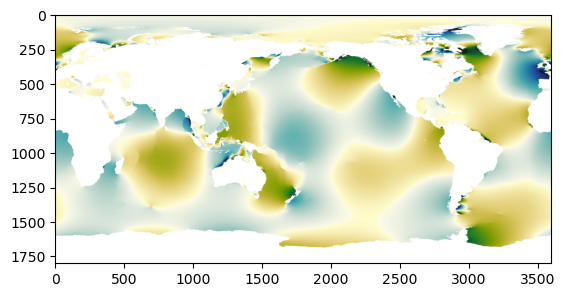

In [11]:
img = Image.open('/g/data/x77/amh157/frames/frame_0001.png')
arr = np.array(img)
plt.imshow(arr)


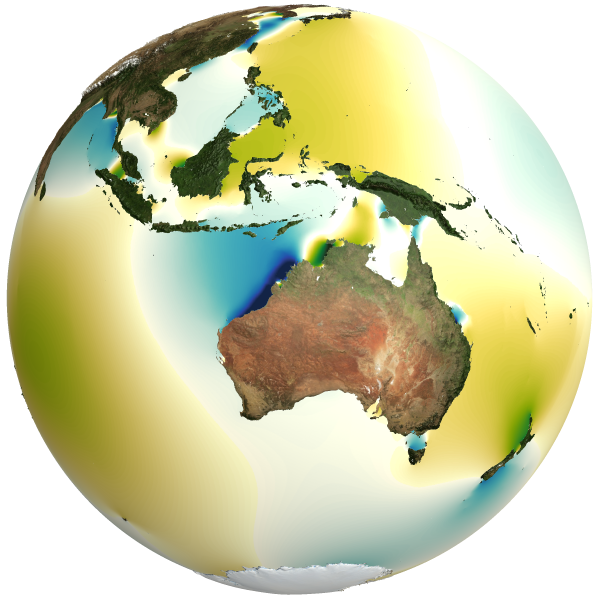

'/g/data/x77/amh157/tide-on-globe.png'

In [17]:
accessvis.update_earth_values(lv, dataMode=1, data=arr)
lv.display(resolution=(600, 600))
lv.rotation(40.0, 230.0, -20)
lv.image(filename='/g/data/x77/amh157/tide-on-globe.png', resolution=(600, 600))

## This is the cell that renders the movie
Note that:
* I've already defined `filename`, above;
* I selected lowest `quality` for testing, but ended up with 2 for final version (scale is 1-3);
* I have slowed down the `fps` to 15 because tides are so fast!! Makes it a bit jumpy.
* Updating the frame with a new image for each iteration
* Plotting with`datamode` set to show ocean data only, so that bluemarnle shows through
* Rotating it by 0.2 units every frame. Not sure how to prescribe the rotation properly, tbh. 

In [23]:
with lv.video(filename=filename, quality=2, fps=15, resolution=(600,600)) as v:
    for ii in range(100):
        img = Image.open('/g/data/x77/amh157/frames/frame_'+f"{ii:04d}"+'.png')
        arr = np.array(img)
        accessvis.update_earth_values(lv, dataMode=1, data=arr)
        lv.rotation(30.0, 230.0-ii*0.2, -20.0)
        lv.render()

    